# Checkpoint Two: Exploratory Data Analysis

Now that your chosen dataset is approved, it is time to start working on your analysis. Use this notebook to perform your EDA and make notes where directed to as you work.

## Getting Started

Since we have not provided your dataset for you, you will need to load the necessary files in this repository. Make sure to include a link back to the original dataset here as well.

My dataset:

Your first task in EDA is to import necessary libraries and create a dataframe(s). Make note in the form of code comments of what your thought process is as you work on this setup task.

In [1]:
#importing all the libraries I might need, especially pandas so that I can import a dataframe
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#importing the csv itself as a dataframe
df=pd.read_csv("Alzheimer's_and_Healthy_Aging.csv")


## Get to Know the Numbers

Now that you have everything setup, put any code that you use to get to know the dataframe and its rows and columns better in the cell below. You can use whatever techniques you like, except for visualizations. You will put those in a separate section.

When working on your code, make sure to leave comments so that your mentors can understand your thought process.

In [2]:
#I'm running the head function to look at the first 5 rows of the data set.
df.head()


,RowId,YearStart,YearEnd,LocationAbbr,LocationDesc,Datasource,Class,Topic,Question,Data_Value_Unit,...,Stratification2,Geolocation,ClassID,TopicID,QuestionID,LocationID,StratificationCategoryID1,StratificationID1,StratificationCategoryID2,StratificationID2
0,BRFSS~2015~2015~66~Q35~TOC03~AGE~SEX,2015,2015,GU,Guam,BRFSS,Overall Health,Recent activity limitations in past month,Mean number of days with activity limitations ...,Number,...,Female,POINT (144.793731 13.444304),C01,TOC03,Q35,66,AGE,AGE_OVERALL,SEX,FEMALE
1,BRFSS~2015~2015~25~Q27~TMC03~AGE~SEX,2015,2015,MA,Massachusetts,BRFSS,Mental Health,Lifetime diagnosis of depression,Percentage of older adults with a lifetime dia...,%,...,Male,POINT (-72.08269067499964 42.27687047000046),C05,TMC03,Q27,25,AGE,65PLUS,SEX,MALE
2,BRFSS~2015~2015~9002~Q43~TOC11~AGE~SEX,2015,2015,MDW,Midwest,BRFSS,Overall Health,Arthritis among older adults,Percentage of older adults ever told they have...,%,...,Male,NaN,C01,TOC11,Q43,9002,AGE,5064,SEX,MALE
3,BRFSS~2015~2015~27~Q03~TMC01~AGE~SEX,2015,2015,MN,Minnesota,BRFSS,Mental Health,Frequent mental distress,Percentage of older adults who are experiencin...,%,...,Male,POINT (-94.79420050299967 46.35564873600049),C05,TMC01,Q03,27,AGE,AGE_OVERALL,SEX,MALE
4,BRFSS~2015~2015~29~Q43~TOC11~AGE~OVERALL,2015,2015,MO,Missouri,BRFSS,Overall Health,Arthritis among older adults,Percentage of older adults ever told they have...,%,...,NaN,POINT (-92.56630005299968 38.635790776000476),C01,TOC11,Q43,29,AGE,AGE_OVERALL,OVERALL,OVERALL


In [3]:
#I'm using the describe function to see some descriptive stats about the data set. I'm not finding this to be super helpful as many of the columns aren't numbers.
df.describe()


,YearStart,YearEnd,Data_Value,Data_Value_Alt,Low_Confidence_Limit,High_Confidence_Limit,LocationID
count,284142.000000,284142.000000,192808.000000,192808.000000,192597.000000,192597.000000,284142.000000
mean,2018.596065,2018.657735,37.676757,37.676757,33.027824,42.595333,800.322677
std,2.302815,2.360105,25.213484,25.213484,24.290016,26.156408,2511.564977
min,2015.000000,2015.000000,0.000000,0.000000,-0.700000,1.300000,1.000000
25%,2017.000000,2017.000000,15.900000,15.900000,12.600000,19.700000,19.000000
50%,2019.000000,2019.000000,32.800000,32.800000,27.000000,38.900000,34.000000
75%,2021.000000,2021.000000,56.900000,56.900000,49.400000,64.600000,49.000000
max,2022.000000,2022.000000,100.000000,100.000000,99.600000,100.000000,9004.000000


In [4]:
#I'm using the info function to see a summary of all the columns and the types of data they hold. This confirms my  previous observation above--most of the columns are objects (strings).
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284142 entries, 0 to 284141
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   RowId                       284142 non-null  object 
 1   YearStart                   284142 non-null  int64  
 2   YearEnd                     284142 non-null  int64  
 3   LocationAbbr                284142 non-null  object 
 4   LocationDesc                284142 non-null  object 
 5   Datasource                  284142 non-null  object 
 6   Class                       284142 non-null  object 
 7   Topic                       284142 non-null  object 
 8   Question                    284142 non-null  object 
 9   Data_Value_Unit             284142 non-null  object 
 10  DataValueTypeID             284142 non-null  object 
 11  Data_Value_Type             284142 non-null  object 
 12  Data_Value                  192808 non-null  float64
 13  Data_Value_Alt

In [5]:
#I am especially interested in data related to Missouri, so I'm going to narrow down one of the data fields.
MO_caregiver_question=df[
    (df['Question']=="Average of 20 or more hours of care per week provided to a friend or family member") & 
        (df['LocationAbbr']== 'MO')
        ]

print(MO_caregiver_question)

                                           RowId  YearStart  YearEnd  \
50024      BRFSS~2016~2016~29~Q39~TGC04~AGE~RACE       2016     2016   
50214      BRFSS~2016~2016~29~Q39~TGC04~AGE~RACE       2016     2016   
50552      BRFSS~2016~2016~29~Q39~TGC04~AGE~RACE       2016     2016   
50576       BRFSS~2016~2016~29~Q39~TGC04~AGE~SEX       2016     2016   
51061      BRFSS~2016~2016~29~Q39~TGC04~AGE~RACE       2016     2016   
...                                          ...        ...      ...   
228335     BRFSS~2021~2022~29~Q39~TGC04~AGE~RACE       2021     2022   
228375     BRFSS~2021~2021~29~Q39~TGC04~AGE~RACE       2021     2021   
228621     BRFSS~2021~2021~29~Q39~TGC04~AGE~RACE       2021     2021   
228939      BRFSS~2021~2022~29~Q39~TGC04~AGE~SEX       2021     2022   
229010  BRFSS~2021~2022~29~Q39~TGC04~AGE~OVERALL       2021     2022   

       LocationAbbr LocationDesc Datasource       Class  \
50024            MO     Missouri      BRFSS  Caregiving   
50214            

In [6]:
#I want to see which Questions have the most null data values, because they might be Questions I want to avoid analyzing.
null_data=df[df['Data_Value'].isnull()]
questions_null_data=null_data['Question'].value_counts()
print(questions_null_data.head())

Question
Percentage of older adults who reported binge drinking within the past 30 days                                                    4451
Percentage of older adults who are experiencing frequent mental distress                                                          4020
Percentage of older adults who have smoked at least 100 cigarettes in their entire life and still smoke every day or some days    3828
Mean number of days with activity limitations in the past month                                                                   3666
Percentage of older adults with a lifetime diagnosis of depression                                                                3656
Name: count, dtype: int64


## Visualize

Create any visualizations for your EDA here. Make note in the form of code comments of what your thought process is for your visualizations.

In [7]:
location_count=df['LocationAbbr'].value_counts()
#I'm going to use the existing categories in the dataframe to look at how many rows exist for each segment of the contiguous US.
west_count=location_count.get('WEST',0)
midwest_count=location_count.get('MDW',0)
northeast_count=location_count.get('NRE',0)
south_count=location_count.get('SOU',0)



<BarContainer object of 4 artists>

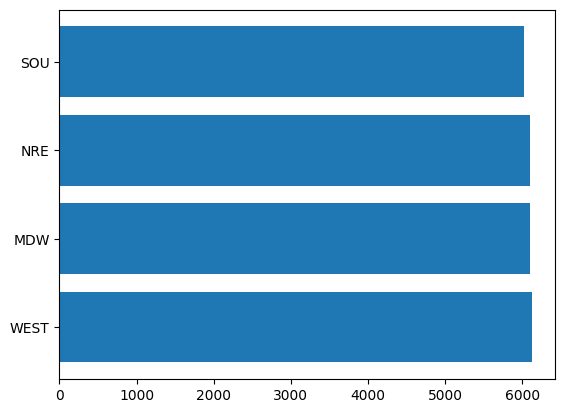

In [8]:
location_count=df['LocationAbbr'].value_counts()
#I'm going to use the existing categories in the dataframe to look at how many rows exist for each segment of the contiguous US.
west_count=location_count.get('WEST',0)
midwest_count=location_count.get('MDW',0)
northeast_count=location_count.get('NRE',0)
south_count=location_count.get('SOU',0)

#I want to create variables to be used in a bar chart.
regions=['WEST','MDW','NRE','SOU']
counts=[west_count,midwest_count,northeast_count,south_count]
plt.barh(regions,counts)

#I wanted to see if each region had the same amount of data available--they look quite closely even in the visual.Only the South might have a minimally smaller number of rows.


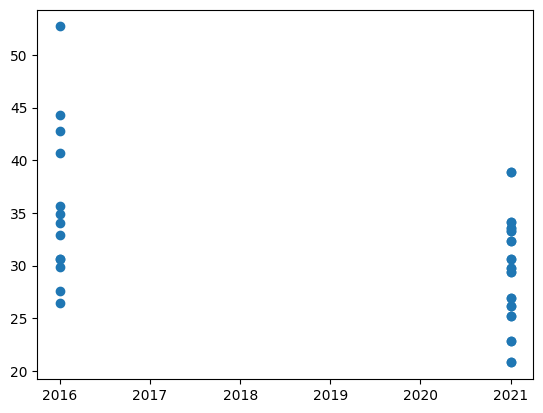

In [9]:
#I want to make a scatter plot to see any trends over time for Missouri & the question about caregivers from above.
plt.scatter(MO_caregiver_question['YearStart'],MO_caregiver_question['Data_Value'])
#I didn't realize there wasn't any data for the years 2017-2020.


## Summarize Your Results

With your EDA complete, answer the following questions.

1. Was there anything surprising about your dataset? 
2. Do you have any concerns about your dataset? 
3. Is there anything you want to make note of for the next phase of your analysis, which is cleaning data? 

1. The data set is both bigger and smaller than I thought. While it does have lots of data for every state over 6 years, there are also a lot of null values.
2. I'm going to need to consider the null values might impede how I hoped to analyze this data. For example, there is only data for 2 years in Missouri as far as the percentage of people who "Average of 20 or more hours of care per week provided to a friend or family member". The data is also going to be complicated to analyze because it is mostly string values, with very few numbers.
3. I will definitely want to carefully evaluate how I handle the null values when I start cleaning the data. Depending on what information I'm seeking, they may need to be removed.
